# Active Discovery of Latent Dynamic Mediators

To start we assume that in our training set we have recordings of $N$ independent patients. Each patient $n$ is associated with two time series signals, $x_n(t)$ and $y_n(t)$, and a treatment group label $c_n \in \mathcal{C}$ provided by an expert. The treatment group $c_n$ identifies which causal pathway is responsible for generating $y_n(t)$. The pathway $c_n$ is associated with a particular causal model $M_{c_n}$ that generated $y_n(t)$  conditional on a latent mediation process $z_n(t)$.

There are two SSMs indexed by $j\in \{0,1\}$:
$$z_t := \alpha_j x_t + \lambda_j z_{t-1} + w_t,
    \qquad w \sim \mathcal{N}(0,\sigma_w)$$
$$y_t := \beta_j z_{t} + \gamma_j x_t + e_t,
    \qquad e_t \sim \mathcal{N}(0,\sigma_e)
$$

In [ ]:
# generate synthetic samples
import numpy as np

def generate_synthetic_samples(
    n_patients=100,
    T=50,
    # Group 0 SSM parameters
    alpha_0=0.6, lambda_0=0.8, beta_0=0.5, gamma_0=0.2,
    sigma_w_0=0.1, sigma_e_0=0.1,
    # Group 1 SSM parameters
    alpha_1=0.3, lambda_1=0.4, beta_1=0.9, gamma_1=0.5,
    sigma_w_1=0.1, sigma_e_1=0.1,
):
    """
    Generates synthetic patient data from two group-specific SSMs:

      State:       z_t = alpha_j * x_t + lambda_j * z_{t-1} + w_t,   w ~ N(0, sigma_w)
      Observation: y_t = beta_j  * z_t  + gamma_j  * x_t   + e_t,   e ~ N(0, sigma_e)

    Returns:
      j  : (n_patients,)       group labels in {0, 1}
      X  : (n_patients, T)     input signals x_t
      Z  : (n_patients, T)     latent states z_t
      Y  : (n_patients, T)     observations y_t
    """
    # Pack parameters per group for clean indexing
    params = {
        0: dict(alpha=alpha_0, lam=lambda_0, beta=beta_0,
                gamma=gamma_0, sigma_w=sigma_w_0, sigma_e=sigma_e_0),
        1: dict(alpha=alpha_1, lam=lambda_1, beta=beta_1,
                gamma=gamma_1, sigma_w=sigma_w_1, sigma_e=sigma_e_1),
    }

    # Assign group labels randomly
    j = np.random.choice([0, 1], size=n_patients)

    # Pre-allocate outputs
    X = np.zeros((n_patients, T))
    Z = np.zeros((n_patients, T))
    Y = np.zeros((n_patients, T))

    for n in range(n_patients):
        p = params[j[n]]

        # Input signal x_t (was random walk, swap for your real signal if available)
        # currently, it is just random
        X[n] = np.random.randn(T) * 0.5

        z_prev = 0.0
        for t in range(T):
            w = np.random.normal(0, p['sigma_w'])
            e = np.random.normal(0, p['sigma_e'])

            z_t = p['alpha'] * X[n, t] + p['lam'] * z_prev + w
            y_t = p['beta']  * z_t     + p['gamma'] * X[n, t] + e

            Z[n, t] = z_t
            Y[n, t] = y_t
            z_prev  = z_t

    return j, X, Z, Y

## Phase 1: training

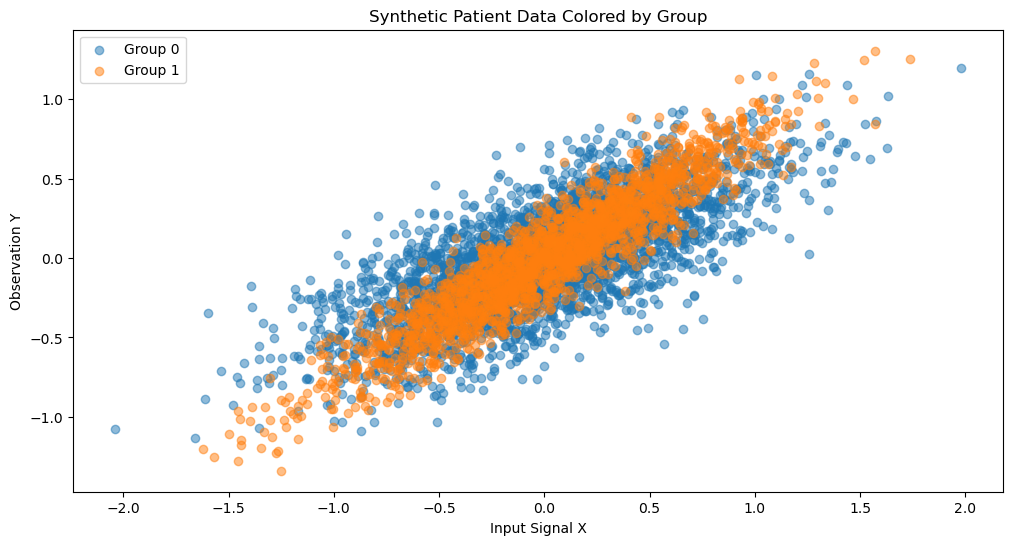

In [10]:
# given the group labels j in {0,1}, we infer the group parameters theta_j = (alpha_j, beta_j, gamma_j, lambda_j) 
# and z_t

# generate synthetic training samples
j_train, X_train, Z_train, Y_train = generate_synthetic_samples(n_patients=100, T=50)

# plot some examples
# color by group
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for group in [0, 1]:
    idx = (j_train == group)
    plt.scatter(X_train[idx].flatten(), Y_train[idx].flatten(), alpha=0.5, label=f'Group {group}')
plt.xlabel('Input Signal X')
plt.ylabel('Observation Y')
plt.title('Synthetic Patient Data Colored by Group')
plt.legend()
plt.show()


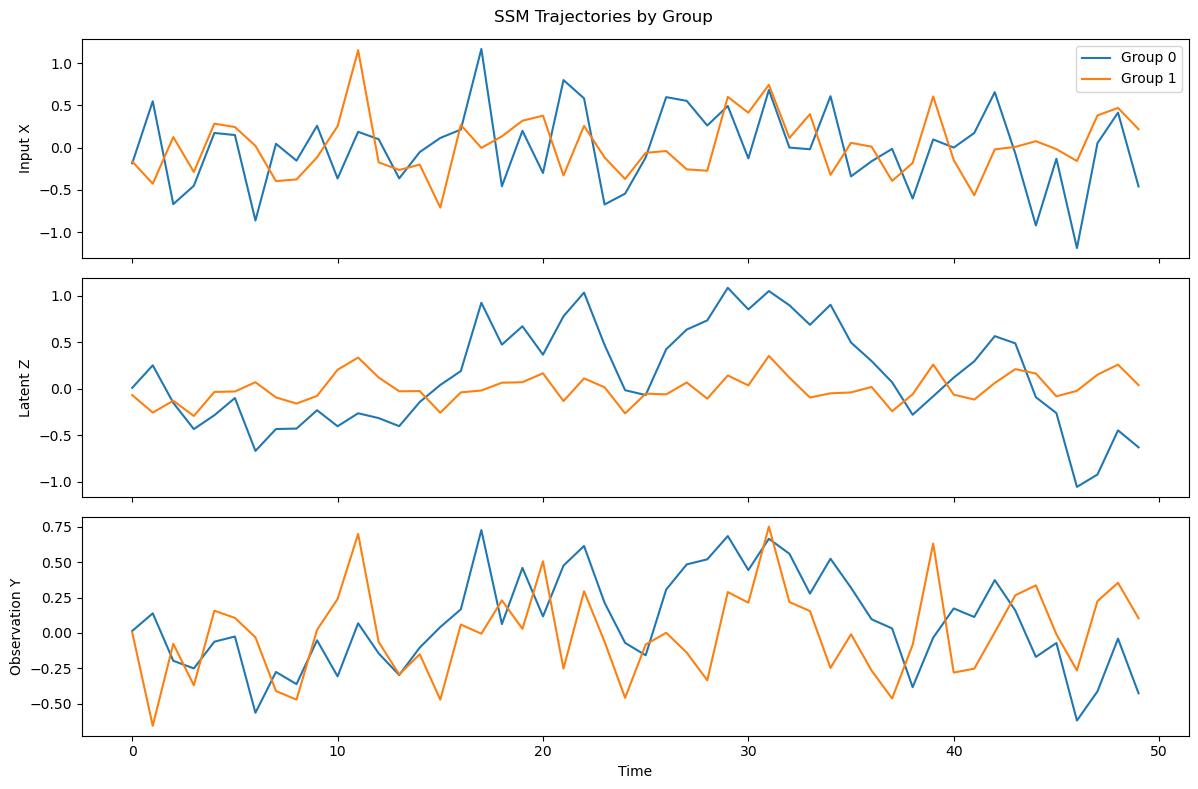

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for group in [0, 1]:
    idx = np.where(j_train == group)[0][0]  # one patient per group
    axes[0].plot(X_train[idx], label=f'Group {group}')
    axes[1].plot(Z_train[idx])
    axes[2].plot(Y_train[idx])

axes[0].set_ylabel('Input X'); axes[0].legend()
axes[1].set_ylabel('Latent Z')
axes[2].set_ylabel('Observation Y')
axes[2].set_xlabel('Time')
plt.suptitle('SSM Trajectories by Group')
plt.tight_layout()
plt.show()

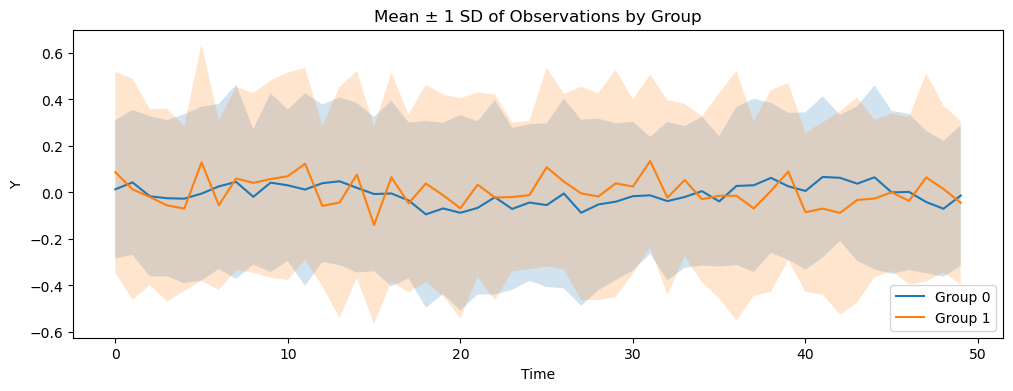

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
for group in [0, 1]:
    idx = (j_train == group)
    mean_y = Y_train[idx].mean(axis=0)
    std_y  = Y_train[idx].std(axis=0)
    t = np.arange(50)
    ax.plot(t, mean_y, label=f'Group {group}')
    ax.fill_between(t, mean_y - std_y, mean_y + std_y, alpha=0.2)

ax.set_xlabel('Time'); ax.set_ylabel('Y')
ax.set_title('Mean ± 1 SD of Observations by Group')
ax.legend()
plt.show()

In [13]:
from utils import fit_mixture_ssm
# fit SSM parameters for each group
results_theta, loglik_theta = fit_mixture_ssm(j_train, X_train, Y_train)


Fitting group 0  (61 patients)
  Final log-lik : 2108.11
  alpha=0.406  lam=0.793  beta=0.758  gamma=0.195  sigma_w=0.065  sigma_e=0.098

Fitting group 1  (39 patients)
  Final log-lik : 1125.28
  alpha=0.459  lam=0.456  beta=0.484  gamma=0.549  sigma_w=0.153  sigma_e=0.109


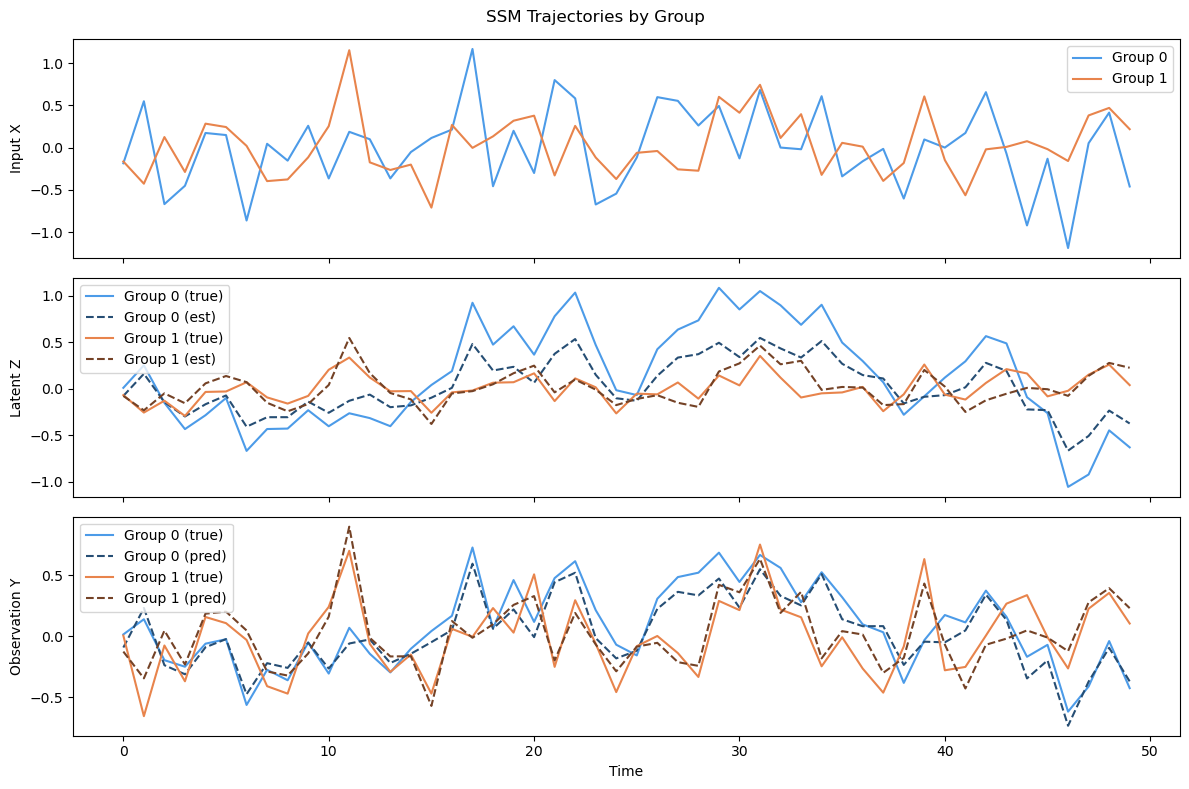

In [14]:
from plot_utils import plot_ssm_trajectories
plot_ssm_trajectories(X_train, Z_train, Y_train, j_train, estimated_params=results_theta)

## Phase 2: classification via filtering

In [15]:
# generate synthetic testing samples
j_test, X_test, Z_test, Y_test = generate_synthetic_samples(n_patients=20, T=50)

In [16]:
from utils import infer_patients
results = infer_patients(Y_test, X_test, results_theta[0], results_theta[1])

# results is a list of 50 dicts, one per patient
# pull out group assignments for all patients at once
j_pred = np.array([r['group'] for r in results])

# pull out smoothed trajectories as a matrix
Z_smooth = np.stack([r['z_smooth'] for r in results])  # (50, 50)
Z_filt   = np.stack([r['z_filt']   for r in results])  # (50, 50)

# -----------------------------------------------------------------------
# Things you might do with the results
# -----------------------------------------------------------------------

# 1. classification accuracy (if you have true labels)
acc = np.mean(j_pred == j_test)
print(f"Accuracy: {acc:.2%}")

# 2. 95% uncertainty band for one patient's smoothed trajectory
n   = 0
z_s = results[n]['z_smooth']
p_s = results[n]['P_smooth']
upper = z_s + 2 * np.sqrt(p_s)
lower = z_s - 2 * np.sqrt(p_s)

# 3. flag ambiguous patients -- small log-likelihood gap means uncertain
gaps = [abs(r['log_liks'][0] - r['log_liks'][1]) for r in results]
ambiguous = np.where(np.array(gaps) < 10)[0]
print(f"Ambiguous patients: {ambiguous}")

# 4. patients where the group assignment may be wrong
# (if you have true labels, look at misclassified ones)
wrong = np.where(j_pred != j_test)[0]
for n in wrong:
    print(f"Patient {n}: true={j_test[n]}, pred={j_pred[n]}, "
          f"ll_gap={gaps[n]:.1f}")

Accuracy: 100.00%
Ambiguous patients: []
